# Rocket Camp 580 Test
3 hours, go

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
import torchvision
from torchvision import datasets, transforms
import torch.nn as nn
import math



: 

### 1. KNN boundaries (20)
Prove that the decision boundary defined by a KNN (with any choice k) for binary classification is continuous. 
</br>(credit to Alex Wang for this question)

### 2. Fast Classification (35)
Using any method of your choice create a model to classify MNIST images. You may not use your test data for training.
</br></br>
You will be scored based on the speed of your classification on 10000 images -- a submission will only be accepted if it achieves > 93% test accuracy (we will test)

In [10]:

def load_mnist(batch_size=32, train=True):
    to_tensor_transform = torchvision.transforms.ToTensor()
    dataset = torchvision.datasets.MNIST(root='./data', train=train, download=True, transform=to_tensor_transform)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    return dataset, dataloader
train_dataset, train_dataloader = load_mnist(batch_size=64, train=True)



#defining model

class mnist(nn.Module):
    def __init__(self):
        super(mnist, self).__init__()
        
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784,32),
            nn.GELU(),
            nn.Linear(32,10)
        )
    def forward(self, x):
        return self.model(x)


mnistmodel = mnist()
loss = nn.CrossEntropyLoss()
lr = 0.001
epochs = 5
optim = torch.optim.Adam(params = mnistmodel.parameters(), lr = lr)


for i in range(epochs):
    for input, output in train_dataloader:
        optim.zero_grad()
        pred = mnistmodel(input)
        losses = loss(pred, output)
        losses.backward()
        optim.step()
print (losses) 





tensor(0.0219, grad_fn=<NllLossBackward0>)


In [8]:
test_dataset, test_dataloader = load_mnist(batch_size=1000, train=False)

mnistmodel.eval()
correct = 0
total = 0
with torch.no_grad():
    for x, y in test_dataloader:
        preds = mnistmodel(x).argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

print(f"Test accuracy: {correct/total*100:.2f}%")

Test accuracy: 95.83%


In [103]:
from time import time
    
subset = torch.utils.data.Subset(train_dataset, range(10000))
subset_loader = DataLoader(subset, batch_size=32, shuffle=False)
start = time()
for input, output in subset:
    mnistmodel(input)
print(time() - start)
# TODO here you should demonstrate the speed of your model on 10000 images from the training set

1.6652348041534424


### 3. Diffusion!    (45)
:) 

### 3.1 Generate data
Generate 2d data and plot it. The data should look like a smiley face and should have ~100 points

<function matplotlib.pyplot.show(close=None, block=None)>

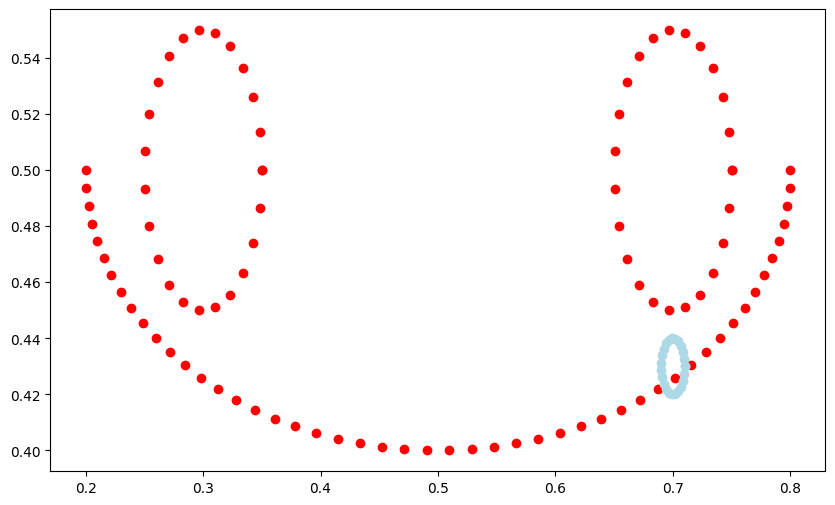

In [2]:

fig, ax = plt.subplots(figsize = (10,6))
def graphsmile():
    # eye 1
    theta = np.linspace(0, 2*np.pi, 24)
    eye1x = 0.3 + 0.05*np.cos(theta)
    eye1y = 0.5 + 0.05*np.sin(theta)
    # eye 2
    eye2x = 0.7 + 0.05*np.cos(theta)
    eye2y = 0.5 + 0.05*np.sin(theta)
    #tear
    thetatear = np.linspace(0, 2*np.pi, 2)
    tearx = 0.7 + 0.01*np.cos(theta)
    teary = 0.43 + 0.01*np.sin(theta)



    # semicrcle
    theta_mouth = np.linspace(np.pi, 2*np.pi, 50)
    mouthx = 0.5 + 0.3*np.cos(theta_mouth)
    mouthy = 0.5 + 0.1*np.sin(theta_mouth)

    ax.scatter(eye1x, eye1y,  color = 'red')
    ax.scatter(eye2x, eye2y,  color = 'red')
    ax.scatter(mouthx, mouthy, color = 'red')
    ax.scatter(tearx,teary, color = 'lightblue')
    return eye1x, eye1y, eye2x, eye2y, tearx, teary, mouthx, mouthy

graphsmile()
plt.show

### 3.2 Create a model
Probably Pytorch but up to you

In [3]:
T = 100
class denoise(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(3,128),
            nn.GELU(),
            nn.Linear(128,256),
            nn.GELU(),
            nn.Linear(256,128),
            nn.GELU(),
            nn.Linear(128,2)
        )
    def forward(self, x, t):
        t = t.view(-1, 1).float()
        return self.model(torch.cat([x,t], dim=1))

model = denoise()

### 3.3 Visualize the vector field
Create a plot showing the magnitude and direction of the error your model predicts given each point from a lattice (grid) of points to show the vector field. </br></br> This will start as random noise, but can be used to diagnose training issues.

### 3.4 Train your model
If you'd like to use the scheduler from the diffusion worksheet you can, but if you're not a coward you can design your own.

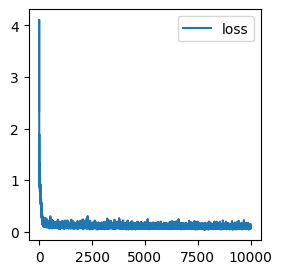

In [4]:

def get_cosine_alpha_bar(t, T=100, s=0.008):
    f_t = math.cos(((t / T) + s) / (1 + s) * (math.pi / 2)) ** 2
    f_0 = math.cos((s / (1 + s)) * (math.pi / 2)) ** 2
    return f_t / f_0

def add_noise(x, t, T=100):
    ab = get_cosine_alpha_bar(t, T)
    noise = torch.randn_like(x)
    x_t = np.sqrt(ab) * x + np.sqrt(1 - ab) * noise
    return x_t, noise

eye1x, eye1y, eye2x, eye2y, tearx, teary, mouthx, mouthy = graphsmile()

data = torch.tensor(np.vstack([
    np.stack([eye1x, eye1y], axis=1),
    np.stack([eye2x, eye2y], axis=1),
    np.stack([tearx,teary],axis = 1),
    np.stack([mouthx, mouthy], axis=1)
]), dtype=torch.float32)





lr = 0.001
loss_fn = nn.MSELoss()
optim = torch.optim.Adam(params=model.parameters(), lr=lr)
epochs = 10000
losstimes = []
lossgraph = []

for i in range(epochs):
    noisy = []
    originals = []
    times = []
    for j in range(len(data)):
        t = torch.randint(0, T, (1,)).item()
        x_t, noise = add_noise(data[j], t, T)
        noisy.append(x_t)
        originals.append(noise)
        times.append(t)

    noisy = torch.stack(noisy)
    originals = torch.stack(originals)
    times = torch.tensor(times)

    optim.zero_grad()
    pred = model(noisy, times)
    losses = loss_fn(pred, originals)
    lossgraph.append(losses.detach().item())
    losstimes.append(i)
    losses.backward()
    optim.step()

fig, losschart = plt.subplots(figsize=(3,3))
losschart.plot(losstimes, lossgraph, label='loss')
plt.legend()
plt.show()

C:\Users\JasonR\AppData\Local\Temp\ipykernel_1652\830078768.py:14: RuntimeWarning: divide by zero encountered in scalar divide
  x = (1/np.sqrt(alphat)) * (x - (bt/np.sqrt(1-abt)) * prednoise)


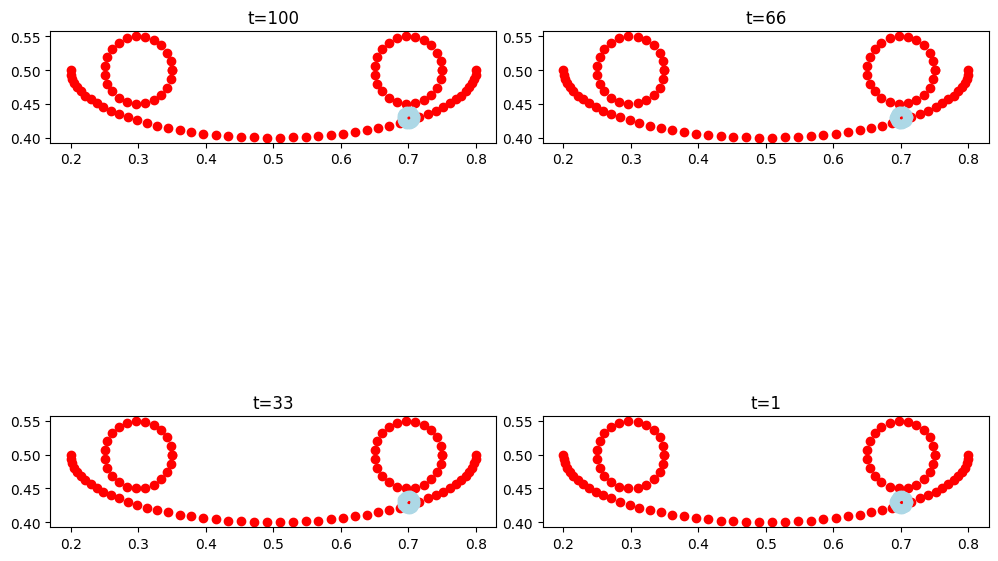

In [9]:
x = torch.randn(len(data), 2)  # start from noise
snapshots = {}
saveat = [100, 66, 33, 1]
abt = get_cosine_alpha_bar(t, T)
abprev = get_cosine_alpha_bar(t-1, T)
bt = 1 - abt/abprev


for t in range(T, 0, -1):
    ttensor = torch.full((len(x),), t, dtype=torch.long)
    prednoise = model(x, ttensor)
    abt = get_cosine_alpha_bar(t, T)
    alphat = 1 - bt
    x = (1/np.sqrt(alphat)) * (x - (bt/np.sqrt(1-abt)) * prednoise)
    if t > 1:
        x = x + np.sqrt(bt) * torch.randn_like(x)
    if t in saveat:
        snapshots[t] = x.detach().clone()

fig, axes = plt.subplots(2, 2, figsize=(10,10))
for ax, t in zip(axes.flat, saveat):
    pts = snapshots[t]
    ax.scatter(pts[:,0], pts[:,1], color='blue')
    ax.set_title(f"t={t}")
    ax.set_aspect('equal')
    graphsmile()
plt.tight_layout()
plt.show()

In [ ]:
hi cooper
so ik this doesnt look to good
BUT
if u look at t=1, the cluster is centered at 0.5,0.5 WHICH is in fact where my smiley face is
so rlly it just looks dumb because of that one point